In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('cookie_cats.csv')

In [3]:
# Removing outlier by filtering impossible sum_gamerounds

df = df[df['sum_gamerounds']<=3000]

In [4]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 90188 entries, 0 to 90188
Data columns (total 5 columns):
userid            90188 non-null int64
version           90188 non-null object
sum_gamerounds    90188 non-null int64
retention_1       90188 non-null bool
retention_7       90188 non-null bool
dtypes: bool(2), int64(2), object(1)
memory usage: 2.9+ MB


In [6]:
df.describe()

,userid,sum_gamerounds
count,9.018800e+04,90188.000000
mean,4.998397e+06,51.320253
std,2.883298e+06,102.682719
min,1.160000e+02,0.000000
25%,2.512211e+06,5.000000
50%,4.995804e+06,16.000000
75%,7.496461e+06,51.000000
max,9.999861e+06,2961.000000


In [7]:
df.groupby('version')['sum_gamerounds'].describe()

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44699.0,51.342111,102.057598,0.0,5.0,17.0,50.0,2961.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


In [8]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# Performing t-test on sum_gamerounds (continuous KPI)
# H0: average sum_gamerounds is the same for gate_30 and gate_40

control = df[df['version']=='gate_30']['sum_gamerounds']
variant = df[df['version']=='gate_40']['sum_gamerounds']

stats.ttest_ind(control, variant, equal_var=False)

Ttest_indResult(statistic=0.063374263128922942, pvalue=0.94946862154644585)

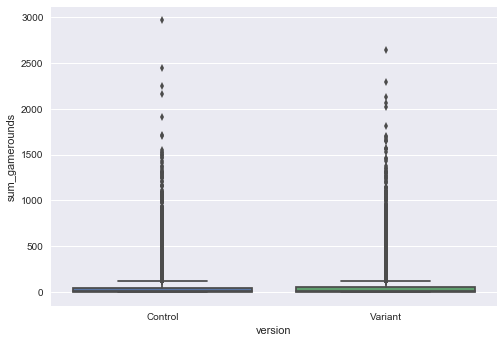

In [10]:
sns.boxplot(data=df, x='version', y='sum_gamerounds')
plt.xticks([0,1], ['Control', 'Variant'])
plt.show()

In [11]:
# Performing chi-square test on retention data (binary outcome)
# H0: retention_1 and retention_7 rates are both independent of game version

for col in ['retention_1', 'retention_7']:
    table = pd.crosstab(df['version'], df[col])
    print(col)
    print(stats.chi2_contingency(table))
    print()

retention_1
(3.169835543170799, 0.07500999897705693, 1, array([[ 24798.35970417,  19900.64029583],
       [ 25236.64029583,  20252.35970417]]))

retention_7
(9.9152755289056707, 0.0016391259678654425, 1, array([[ 36382.49203885,   8316.50796115],
       [ 37025.50796115,   8463.49203885]]))



In [12]:
# retention_7 is stat-sig, so compare retention rates to quantify the magnitude of observed effect

df.groupby('version')[['retention_1', 'retention_7']].mean()

,retention_1,retention_7
version,,
gate_30,0.448198,0.190183
gate_40,0.442283,0.182000


In [13]:
# lift calculation
# 7-day retention decreased by 4.3% in the variant group

(0.182000 - 0.190183) / 0.190183

-0.043026979277853414